## Model Training

In [44]:
# import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score,accuracy_score
from sklearn.model_selection import RandomizedSearchCV

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import pickle

In [46]:
import os

data_path = os.path.join('..', 'data', 'cleaned_telecom.csv')
data = pd.read_csv(data_path)
data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
# droping customerID column
data.drop('customerID',axis=1,inplace=True)

In [48]:
# convert total charges to numeric
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)

C:\Users\G POORNIMADEVI\AppData\Local\Temp\ipykernel_16808\2633768186.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


In [49]:
# Feature engineering

In [50]:
# How much of total charges is monthly? High ratio = newer customer
data['charge_ratio'] = data['MonthlyCharges'] / (data['TotalCharges'] + 1)

In [51]:
# Bin tenure into categories
data['tenure_group'] = pd.cut(data['tenure'], 
                             bins=[0, 12, 24, 48, 72],
                             labels=[0, 1, 2, 3])
# Convert categorical to numeric
data['tenure_group'] = data['tenure_group'].cat.codes

In [52]:
# How many add-on services does the customer have?
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']

data['service_count'] = data[service_cols].apply(
    lambda x: x.str.contains('Yes').sum(), axis=1)

In [53]:
# Total charges normalized by tenure
data['avg_monthly_revenue'] = data['TotalCharges'] / (data['tenure'] + 1)

In [54]:
# Customers in first 6 months are high risk
data['is_new_customer'] = (data['tenure'] <= 6).astype(int)

In [55]:
# High paying customer who might leave
data['high_value_at_risk'] = (
    (data['MonthlyCharges'] > data['MonthlyCharges'].median()) & 
    (data['tenure'] <= 12)
).astype(int)

In [56]:
# encoding binary categorical features

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
from sklearn.preprocessing import LabelEncoder
for col in binary_cols:
    data[col] = LabelEncoder().fit_transform(data[col])

In [57]:
# ont-hot encoding for multi-class categorical features
multi_class_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=multi_class_cols)

In [58]:
# splitting data into features and target variable
X = data.drop('Churn', axis=1)
y = data['Churn']

In [59]:
# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
smote = SMOTE()
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)  # ✅

In [60]:
# feature scaling
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)

In [61]:
# Initialize models
rf_model = RandomForestClassifier(n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42)
log_model = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    random_state=42
)
xgb = XGBClassifier(    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42)

In [62]:
# Random Forest
rf_model.fit(X_train_res, y_train_res)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]



In [63]:
# Logistic Regression
log_model.fit(X_train_res, y_train_res)
log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]


In [64]:
# Decision Tree
dt.fit(X_train_res, y_train_res)
dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]


In [65]:
# XGBoost
xgb.fit(X_train_res, y_train_res)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]



In [66]:
# Instead of default 0.5 threshold:
y_pred_adjusted = (xgb_proba >= 0.35).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1539
           1       0.57      0.71      0.63       574

    accuracy                           0.78      2113
   macro avg       0.73      0.76      0.74      2113
weighted avg       0.80      0.78      0.78      2113



In [67]:
def evaluate_model(y_test, y_pred, y_prob, model_name):

    print("="*50)
    print(f"Model : {model_name}")
    print("="*50)

    accuracy = accuracy_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy Score : {accuracy:.4f}")

    print(f"ROC AUC Score : {roc_auc:.4f}")

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))
    print("\n\n")

In [68]:
#Evauluate Random Forest
evaluate_model(y_test, rf_pred, rf_proba, "Random Forest")

Model : Random Forest
Accuracy Score : 0.7908
ROC AUC Score : 0.8514

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1539
           1       0.60      0.67      0.64       574

    accuracy                           0.79      2113
   macro avg       0.74      0.75      0.74      2113
weighted avg       0.80      0.79      0.79      2113


Confusion Matrix

[[1286  253]
 [ 189  385]]





In [69]:
# Evaluate Decision Tree
evaluate_model(y_test, dt_pred, dt_proba, "Decision Tree")

Model : Decision Tree
Accuracy Score : 0.7686
ROC AUC Score : 0.8111

Classification Report

              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1539
           1       0.57      0.64      0.60       574

    accuracy                           0.77      2113
   macro avg       0.71      0.73      0.72      2113
weighted avg       0.78      0.77      0.77      2113


Confusion Matrix

[[1256  283]
 [ 206  368]]





In [70]:
# Evaluate Logistic Regression
evaluate_model(y_test, log_pred, log_proba, "Logistic Regression")


Model : Logistic Regression
Accuracy Score : 0.7989
ROC AUC Score : 0.8589

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1539
           1       0.64      0.58      0.61       574

    accuracy                           0.80      2113
   macro avg       0.75      0.73      0.74      2113
weighted avg       0.79      0.80      0.80      2113


Confusion Matrix

[[1355  184]
 [ 241  333]]





In [71]:
# Evaluate XGBoost
evaluate_model(y_test, xgb_pred, xgb_proba, "XGBoost")

Model : XGBoost
Accuracy Score : 0.7899
ROC AUC Score : 0.8410

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1539
           1       0.62      0.57      0.60       574

    accuracy                           0.79      2113
   macro avg       0.73      0.72      0.73      2113
weighted avg       0.78      0.79      0.79      2113


Confusion Matrix

[[1342  197]
 [ 247  327]]





In [72]:
# Model Comparison
models = ['Random Forest', 'Decision Tree', 'Logistic Regression', 'XGBoost']
accuracy_scores = [accuracy_score(y_test, rf_pred), accuracy_score(y_test, dt_pred), accuracy_score(y_test, log_pred), accuracy_score(y_test, xgb_pred)]
roc_auc_scores = [roc_auc_score(y_test, rf_proba), roc_auc_score(y_test, dt_proba), roc_auc_score(y_test, log_proba), roc_auc_score(y_test, xgb_proba)]
comparison_df = pd.DataFrame({'Model': models, 'Accuracy': accuracy_scores, 'ROC AUC': roc_auc_scores})
print(comparison_df)


                 Model  Accuracy   ROC AUC
0        Random Forest  0.790819  0.851421
1        Decision Tree  0.768575  0.811085
2  Logistic Regression  0.798864  0.858937
3              XGBoost  0.789872  0.841016


In [73]:
# Hyperparameter tuning for XGBoost


param_grid = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5]
}


xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=50,           # tries 50 random combinations
    scoring='roc_auc',   # optimize for ROC AUC
    cv=5,                # 5-fold cross validation
    verbose=2,           # shows progress
    random_state=42,
    n_jobs=-1            # use all CPU cores
)


search.fit(X_train_res, y_train_res)


print("Best Parameters:", search.best_params_)
print("Best CV ROC AUC:", search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}
Best CV ROC AUC: 0.9386202081626551


In [74]:
best_xgb = search.best_estimator_

# Predict
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]

# Apply tuned threshold
y_pred_tuned = (y_proba >= 0.35).astype(int)

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))

ROC AUC: 0.8495793458352294
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1539
           1       0.57      0.75      0.65       574

    accuracy                           0.78      2113
   macro avg       0.73      0.77      0.74      2113
weighted avg       0.81      0.78      0.79      2113

[[1214  325]
 [ 142  432]]


In [75]:
# Instead of default 0.5 threshold:
y_pred_tuned = (xgb_proba >= 0.35).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1539
           1       0.57      0.71      0.63       574

    accuracy                           0.78      2113
   macro avg       0.73      0.76      0.74      2113
weighted avg       0.80      0.78      0.78      2113



In [76]:
#hyperparameter tuning for logistic regression
param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}   
log_base = LogisticRegression(random_state=42)
search_log = RandomizedSearchCV(
    estimator=log_base,
    param_distributions=param_grid_log,
    n_iter=20,           # tries 20 random combinations
    scoring='roc_auc',   # optimize for ROC AUC
    cv=5,                # 5-fold cross validation
    verbose=2,           # shows progress
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
search_log.fit(X_train_res, y_train_res)
print("Best Parameters for Logistic Regression:", search_log.best_params_)
print("Best CV ROC AUC for Logistic Regression:", search_log.best_score_)
best_log = search_log.best_estimator_


Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\G POORNIMADEVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 10 is smaller than n_iter=20. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Parameters for Logistic Regression: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
Best CV ROC AUC for Logistic Regression: 0.937268153686931


c:\Users\G POORNIMADEVI\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [77]:
#evaluate tuned logistic regression
y_pred_log = best_log.predict(X_test)
y_proba_log = best_log.predict_proba(X_test)[:, 1]
y_pred_log_tuned = (y_proba_log >= 0.35).astype(int)
print("ROC AUC for Tuned Logistic Regression:", roc_auc_score(y_test, y_proba_log))
print(classification_report(y_test, y_pred_log_tuned))
print(confusion_matrix(y_test, y_pred_log_tuned))

ROC AUC for Tuned Logistic Regression: 0.85876728859185
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      1539
           1       0.58      0.76      0.66       574

    accuracy                           0.78      2113
   macro avg       0.74      0.78      0.75      2113
weighted avg       0.81      0.78      0.79      2113

[[1217  322]
 [ 137  437]]


In [78]:
# Best model is logistic regression, saving the model and scaler for future use

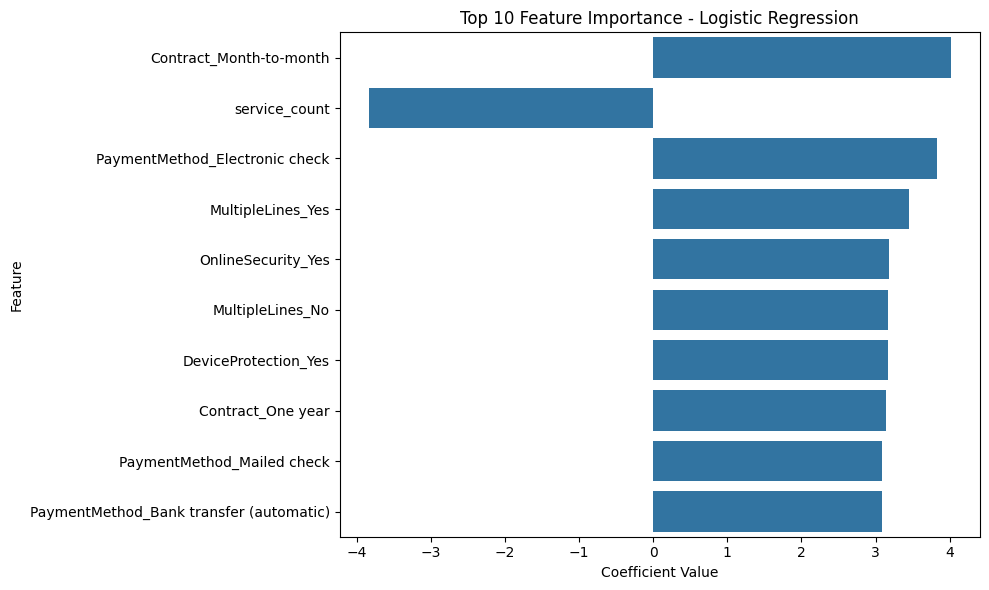

In [79]:
# Plotting Top 10 Feature Importances for logistic regression

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get coefficients from tuned model
feature_importances = best_log.coef_[0]

# Get feature names
feature_names = X.columns

# Create dataframe
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by absolute values because coefficients can be negative
feat_imp_df['abs_importance'] = abs(feat_imp_df['Importance'])

top_features = feat_imp_df.sort_values(
    by='abs_importance',
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top 10 Feature Importance - Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [80]:
# Top model is XGBoost, saving the model and scaler for future use

model_info = {
    'model': best_xgb,
    'scaler': scaler,
    'threshold': 0.30
}
pickle.dump(model_info, open('../models/churn_model_final.pkl', 'wb')) 